# Map & Path Visualization + Metrics
Vẽ bản đồ, đường đi và đo chỉ số chi phí bằng `src/costs`.
Tham số lấy từ `configs/<scenario>.yaml` — **chỉ sửa `CONFIG_FILE` ở cell dưới**.

In [10]:
# ─────────────────────────────────────────
# CẤU HÌNH  ← chỉ chỉnh ở đây
# ─────────────────────────────────────────
CONFIG_FILE   = "configs/scenario7.yaml"   # đổi scenario → mọi thứ tự cập nhật
SHOW_GRID     = True    # kẻ lưới ô
SAVE_FIG_PATH = None    # None = chỉ hiện; vd "results/path_vis.png" để lưu

In [11]:
# ─────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path

_ROOT = os.path.abspath(".")
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from src.utils.io_utils         import load_yaml
from src.environment.map_loader import load_grid_map
from src.costs.total_cost       import CostWeights, path_cost_components

In [12]:
# ─────────────────────────────────────────
# LOAD CONFIG → MAP + PATH + METRICS REF
# ─────────────────────────────────────────
config   = load_yaml(CONFIG_FILE)
grid_map = load_grid_map(config)
weights  = CostWeights.from_config(config)

# JSON kết quả nằm trong output_dir của chính config → luôn khớp với map
output_dir = config["project"]["output_dir"]
json_file  = Path(output_dir) / "paths" / "route_summary.json"

with open(json_file, encoding="utf-8") as f:
    route_data = json.load(f)

PATH         = [tuple(p) for p in route_data["full_path"]]
json_metrics = route_data.get("full_path_components", {})

obs, rad     = grid_map.obstacle_grid, grid_map.radiation_grid
nrows, ncols = obs.shape

print(f"Config      : {CONFIG_FILE}")
print(f"Results     : {json_file}")
print(f"Map size    : {nrows} × {ncols}")
print(f"Path steps  : {len(PATH)}")
print(f"Targets     : {(obs == 2).sum()}   Obstacles: {(obs == 1).sum()}")
print(f"ri_max      : {grid_map.ri_max}")
print(f"Weights     : ω_L={weights.omega_length}  ω_R={weights.omega_risk}  "
      f"ω_E={weights.omega_energy}  ω_CR={weights.omega_collision_risk}")

Config      : configs/scenario7.yaml
Results     : results\scenario7\paths\route_summary.json
Map size    : 100 × 100
Path steps  : 821
Targets     : 60   Obstacles: 861
ri_max      : 8.0
Weights     : ω_L=0.5  ω_R=0.0  ω_E=0.0  ω_CR=0.5


  PATH METRICS  [configs/scenario7.yaml]
  Metric                      ω        Computed            JSON
--------------------------------------------------------------------
  Length        (m)        0.50        956.6905        956.6905
  Risk      (Sv·h)         0.00          0.3873          0.3873
  Energy  (turns)          0.00        145.4750        145.4750
  Collision Risk           0.50        103.4919        103.4919
--------------------------------------------------------------------
  Total Cost                           530.0912        530.0912
  Steps: 821   Unique cells: 809


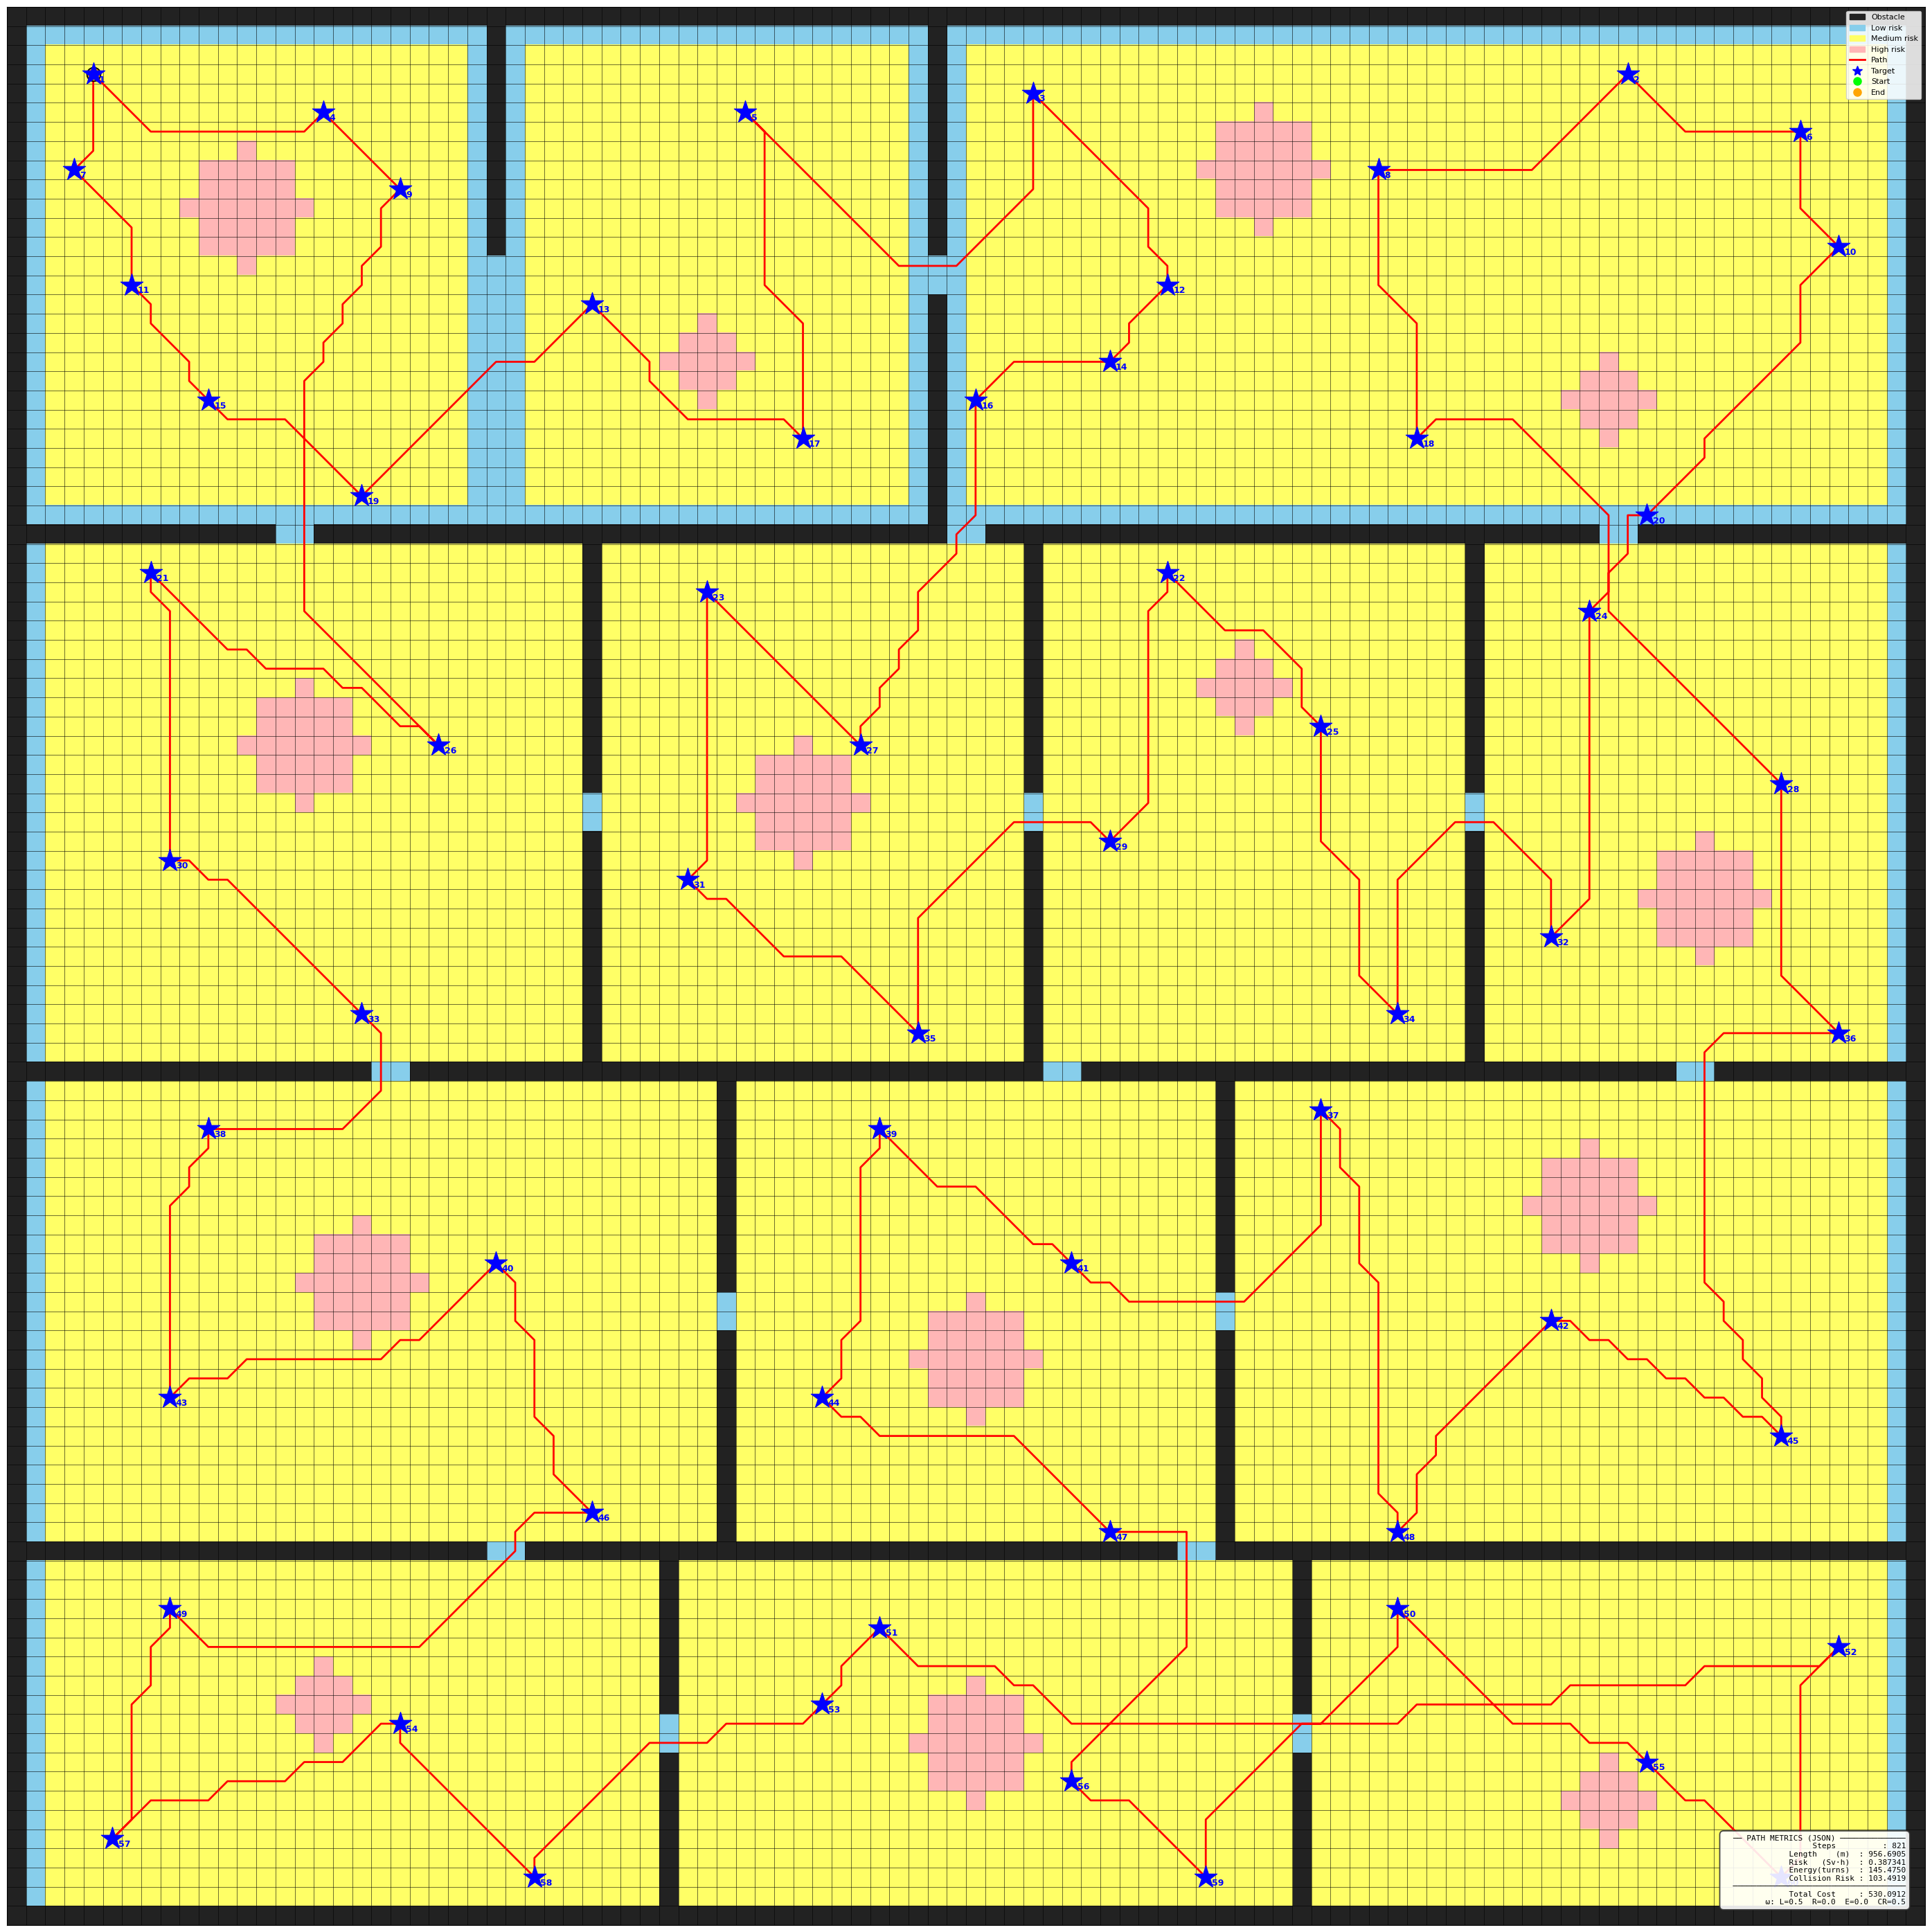

In [13]:
# ─────────────────────────────────────────
# TÍNH METRICS (src/costs) + VẼ BẢN ĐỒ
# ─────────────────────────────────────────

# ── 1. Tính chỉ số ──────────────────────────────────────────────
computed = path_cost_components(grid_map, PATH, weights)

# ── 2. Bảng so sánh ─────────────────────────────────────────────
LABELS = {
    "length":         "Length        (m)",
    "risk":           "Risk      (Sv·h)",
    "energy":         "Energy  (turns)",
    "collision_risk": "Collision Risk",
    "total":          "Total Cost",
}
W = {
    "length":         weights.omega_length,
    "risk":           weights.omega_risk,
    "energy":         weights.omega_energy,
    "collision_risk": weights.omega_collision_risk,
}
print("=" * 68)
print(f"  PATH METRICS  [{CONFIG_FILE}]")
print("=" * 68)
print(f"  {'Metric':<22}  {'ω':>5}  {'Computed':>14}  {'JSON':>14}")
print("-" * 68)
for key in ["length", "risk", "energy", "collision_risk"]:
    jval  = json_metrics.get(key)
    j_str = f"{jval:>14.4f}" if isinstance(jval, (int, float)) else f"{'N/A':>14}"
    print(f"  {LABELS[key]:<22}  {W[key]:>5.2f}  {computed[key]:>14.4f}  {j_str}")
print("-" * 68)
jt   = json_metrics.get("total")
jt_s = f"{jt:>14.4f}" if isinstance(jt, (int, float)) else f"{'N/A':>14}"
print(f"  {LABELS['total']:<22}  {'':>5}  {computed['total']:>14.4f}  {jt_s}")
print("=" * 68)
print(f"  Steps: {len(PATH)}   Unique cells: {len(set(PATH))}")

# ── 3. Vẽ bản đồ ────────────────────────────────────────────────
base = np.ones((nrows, ncols), dtype=int)
base[rad >= 0.5]             = 2   # medium risk
base[rad >= grid_map.ri_max] = 3   # high risk
base[obs == 1]               = 0   # obstacle

cmap_map = ListedColormap(["#222222", "#87CEEB", "#FFFF66", "#FFB6B6"])
fig, ax  = plt.subplots(figsize=(max(12, ncols * 0.28), max(9, nrows * 0.28)))
ax.imshow(base, cmap=cmap_map, vmin=0, vmax=3,
          origin="upper", interpolation="nearest")

# Đường đi
if PATH:
    xs = [p[1] for p in PATH]; ys = [p[0] for p in PATH]
    ax.plot(xs, ys, color="red", linewidth=2.0, zorder=4)
    ax.scatter(xs[0],  ys[0],  s=200, c="lime",   edgecolors="black",
               linewidths=1.2, zorder=6, marker="o")
    ax.scatter(xs[-1], ys[-1], s=200, c="orange", edgecolors="black",
               linewidths=1.2, zorder=6, marker="o")

# Targets
for idx, (r, c) in enumerate(np.argwhere(obs == 2), start=1):
    ax.scatter(c, r, marker="*", s=600, c="blue",
               edgecolors="blue", linewidths=0.8, zorder=8)
    ax.text(c + 0.3, r + 0.3, str(idx), color="blue",
            fontsize=9, fontweight="bold", ha="left", va="center", zorder=9)

# Lưới
if SHOW_GRID:
    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)

ax.set_xlim(-0.5, ncols - 0.5)
ax.set_ylim(nrows - 0.5, -0.5)
ax.set_aspect("equal")

# ── 4. Text-box chỉ số (góc dưới phải) ──────────────────────────
disp      = json_metrics if json_metrics else computed
src_label = "JSON" if json_metrics else "Computed"

box_text = "\n".join([
    f"── PATH METRICS ({src_label}) ──────────────",
    f"  Steps          : {len(PATH)}",
    f"  Length    (m)  : {disp.get('length',         computed['length']):.4f}",
    f"  Risk   (Sv·h)  : {disp.get('risk',           computed['risk']):.6f}",
    f"  Energy(turns)  : {disp.get('energy',         computed['energy']):.4f}",
    f"  Collision Risk : {disp.get('collision_risk', computed['collision_risk']):.4f}",
    f"  ─────────────────────────────────────",
    f"  Total Cost     : {disp.get('total',          computed['total']):.4f}",
    f"  ω: L={weights.omega_length}  R={weights.omega_risk}  "
    f"E={weights.omega_energy}  CR={weights.omega_collision_risk}",
])
ax.text(
    0.99, 0.01, box_text,
    transform=ax.transAxes, fontsize=8, family="monospace",
    va="bottom", ha="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
              alpha=0.90, edgecolor="#333333", linewidth=1.3),
    zorder=10,
)

legend_items = [
    mpatches.Patch(color="#222222", label="Obstacle"),
    mpatches.Patch(color="#87CEEB", label="Low risk"),
    mpatches.Patch(color="#FFFF66", label="Medium risk"),
    mpatches.Patch(color="#FFB6B6", label="High risk"),
    plt.Line2D([0],[0], color="red",    linewidth=2,   label="Path"),
    plt.Line2D([0],[0], marker="*",     color="blue",  linestyle="None",
               markersize=10, label="Target"),
    plt.Line2D([0],[0], marker="o",     color="lime",  linestyle="None",
               markersize=8,  label="Start"),
    plt.Line2D([0],[0], marker="o",     color="orange",linestyle="None",
               markersize=8,  label="End"),
]
ax.legend(handles=legend_items, loc="upper right", fontsize=8, framealpha=0.85)
fig.tight_layout()

if SAVE_FIG_PATH:
    Path(SAVE_FIG_PATH).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_FIG_PATH, dpi=150, bbox_inches="tight")
    print(f"Saved → {SAVE_FIG_PATH}")

plt.show()